Объектов после очистки: 3584, признаков: 14


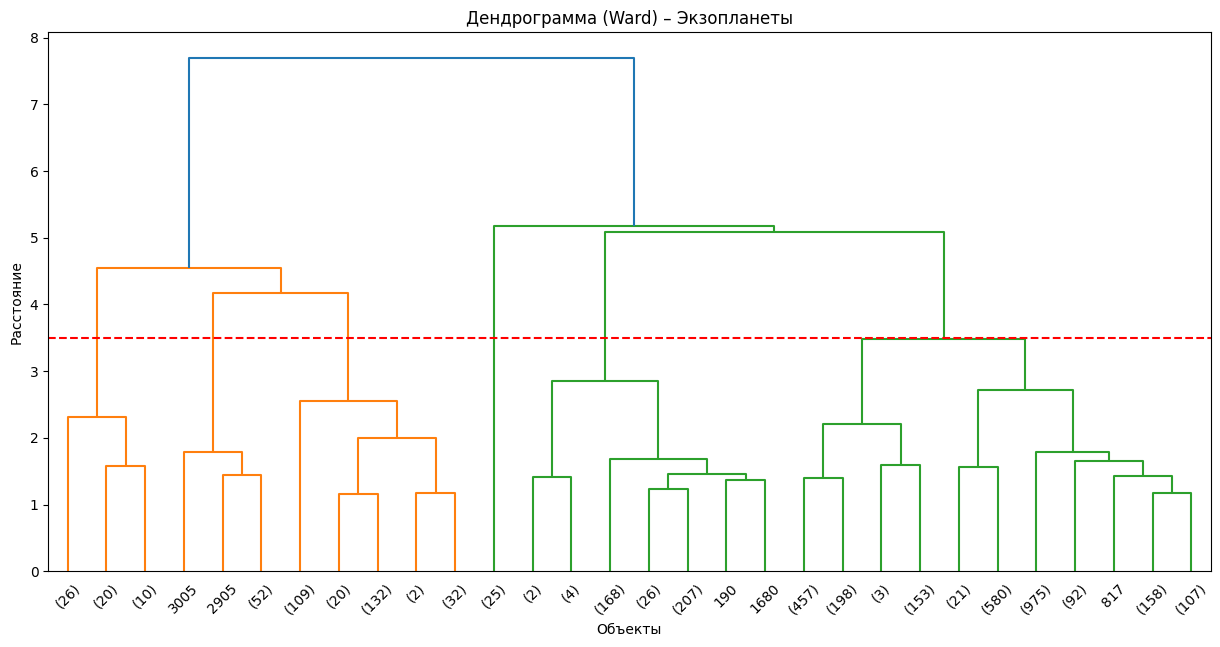

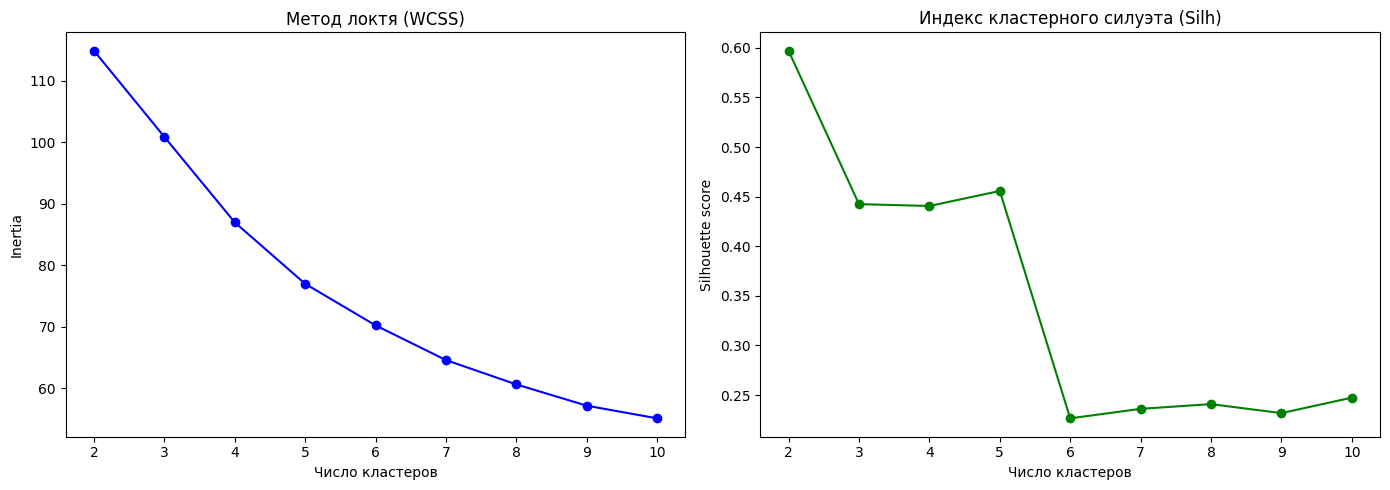

Оптимальное число кластеров по силуэту: 2

K-Means Silhouette: 0.5971
Fuzzy C-Means Silhouette: 0.3492


C:\Users\garazhi\Documents\GitHub\praktika_metody_ii\MII\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


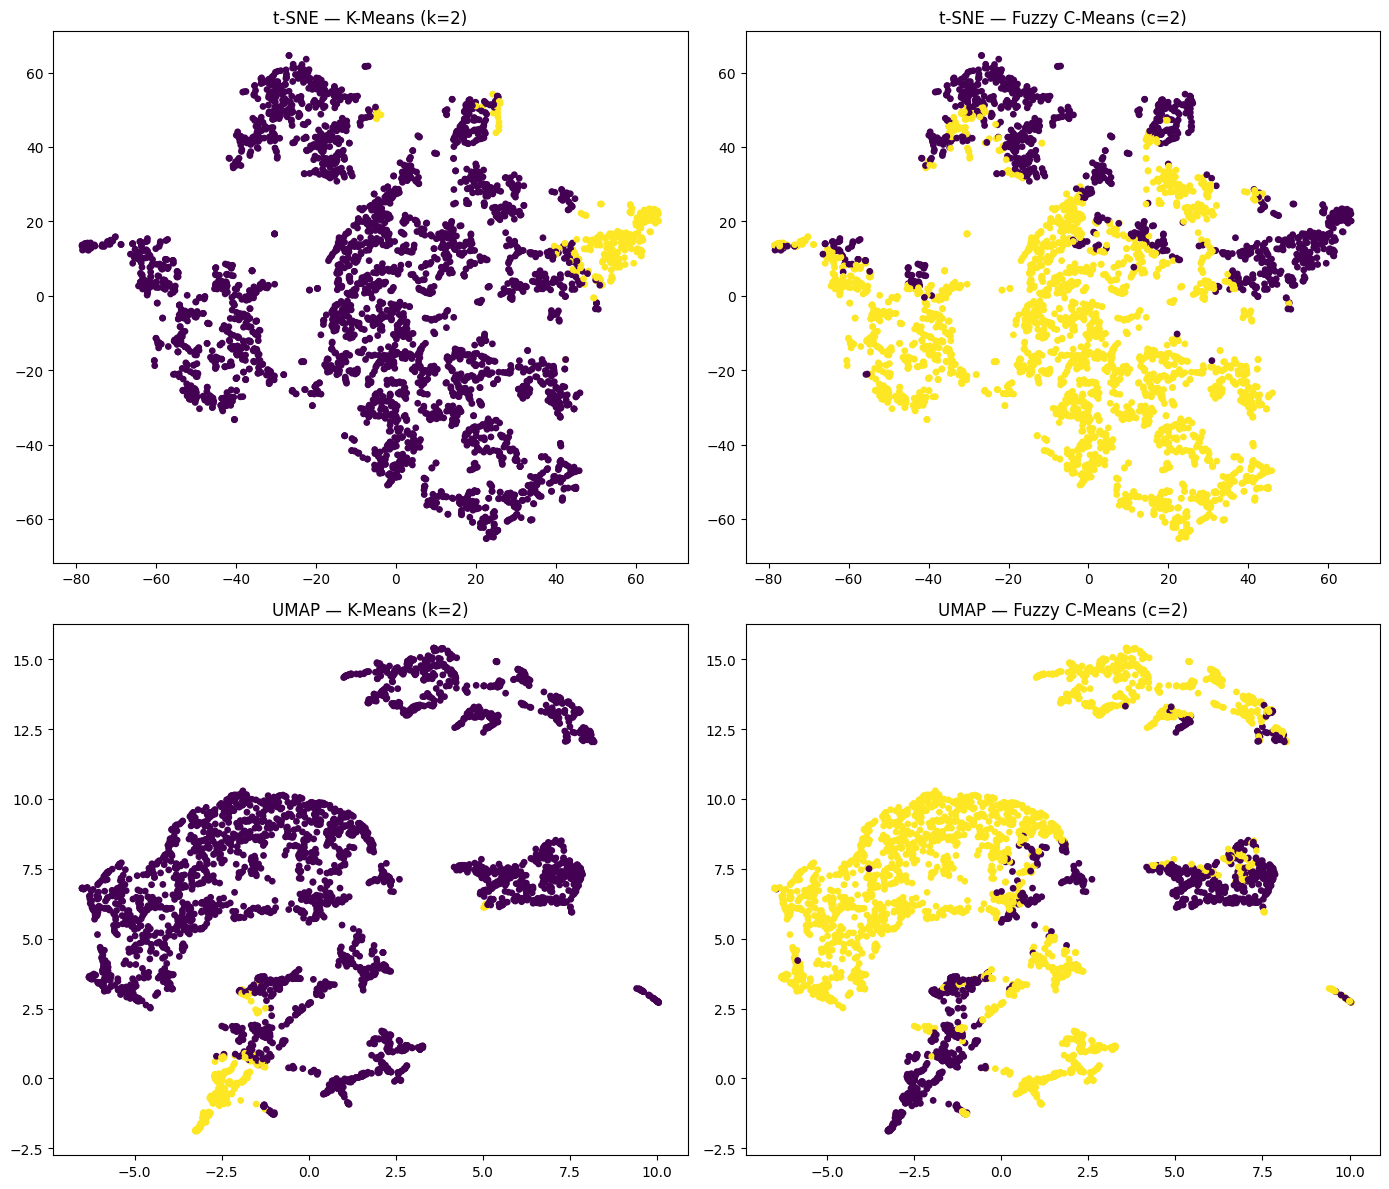


Средние значения признаков по кластерам (K-Means):
         PlanetaryMassJpt  RadiusJpt   PeriodDays  SemiMajorAxisAU  \
cluster                                                              
0                2.361515   0.365328   336.828401         1.824781   
1                5.370779   0.990777  3347.446543         2.915921   

         Eccentricity  InclinationDeg  SurfaceTempK   AgeGyr  \
cluster                                                        
0            0.085061       82.651988    971.982160  1.50275   
1            0.472620       88.002775    400.454615      NaN   

         DistFromSunParsec  HostStarMassSlrMass  HostStarRadiusSlrRad  \
cluster                                                                 
0               605.584618             0.974267              1.375934   
1               123.066957             1.116591              3.700726   

         HostStarMetallicity  HostStarTempK  HostStarAgeGyr  
cluster                                                

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import skfuzzy as fuzz


df = pd.read_csv('oec.csv')

numeric_cols = ['PlanetaryMassJpt', 'RadiusJpt', 'PeriodDays', 'SemiMajorAxisAU',
                'Eccentricity', 'InclinationDeg', 'SurfaceTempK', 'AgeGyr',
                'DistFromSunParsec', 'HostStarMassSlrMass', 'HostStarRadiusSlrRad',
                'HostStarMetallicity', 'HostStarTempK', 'HostStarAgeGyr']
df_num = df[numeric_cols].copy()

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_num)

scaler = preprocessing.MinMaxScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"Объектов после очистки: {X_scaled.shape[0]}, признаков: {X_scaled.shape[1]}")


distance_matrix = linkage(X_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(15, 7))
dendrogram(distance_matrix, truncate_mode='lastp', p=30, leaf_font_size=10)
plt.title("Дендрограмма (Ward) – Экзопланеты")
plt.xlabel("Объекты")
plt.ylabel("Расстояние")
plt.axhline(y=3.5, color='r', linestyle='--')
plt.show()


sil_scores = []
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, metric='euclidean'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Метод локтя (WCSS)')
axes[0].set_xlabel('Число кластеров')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'go-')
axes[1].set_title('Индекс кластерного силуэта (Silh)')
axes[1].set_xlabel('Число кластеров')
axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(sil_scores)]
print(f"Оптимальное число кластеров по силуэту: {optimal_k}")


kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)


cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T, c=optimal_k, m=2, error=0.005, maxiter=300, seed=42
)
fcm_labels = np.argmax(u, axis=0)

print(f"\nK-Means Silhouette: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"Fuzzy C-Means Silhouette: {silhouette_score(X_scaled, fcm_labels):.4f}")


from sklearn.manifold import TSNE
import umap


tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

umap_reducer = umap.UMAP(random_state=42)
X_umap = umap_reducer.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='viridis', s=15)
axes[0, 0].set_title(f't-SNE — K-Means (k={optimal_k})')

axes[0, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=fcm_labels, cmap='viridis', s=15)
axes[0, 1].set_title(f't-SNE — Fuzzy C-Means (c={optimal_k})')

axes[1, 0].scatter(X_umap[:, 0], X_umap[:, 1], c=kmeans_labels, cmap='viridis', s=15)
axes[1, 0].set_title(f'UMAP — K-Means (k={optimal_k})')

axes[1, 1].scatter(X_umap[:, 0], X_umap[:, 1], c=fcm_labels, cmap='viridis', s=15)
axes[1, 1].set_title(f'UMAP — Fuzzy C-Means (c={optimal_k})')

plt.tight_layout()
plt.show()

df_num['cluster'] = kmeans_labels
print("\nСредние значения признаков по кластерам (K-Means):")
print(df_num.groupby('cluster').mean())

Объектов: 339, признаков: 17


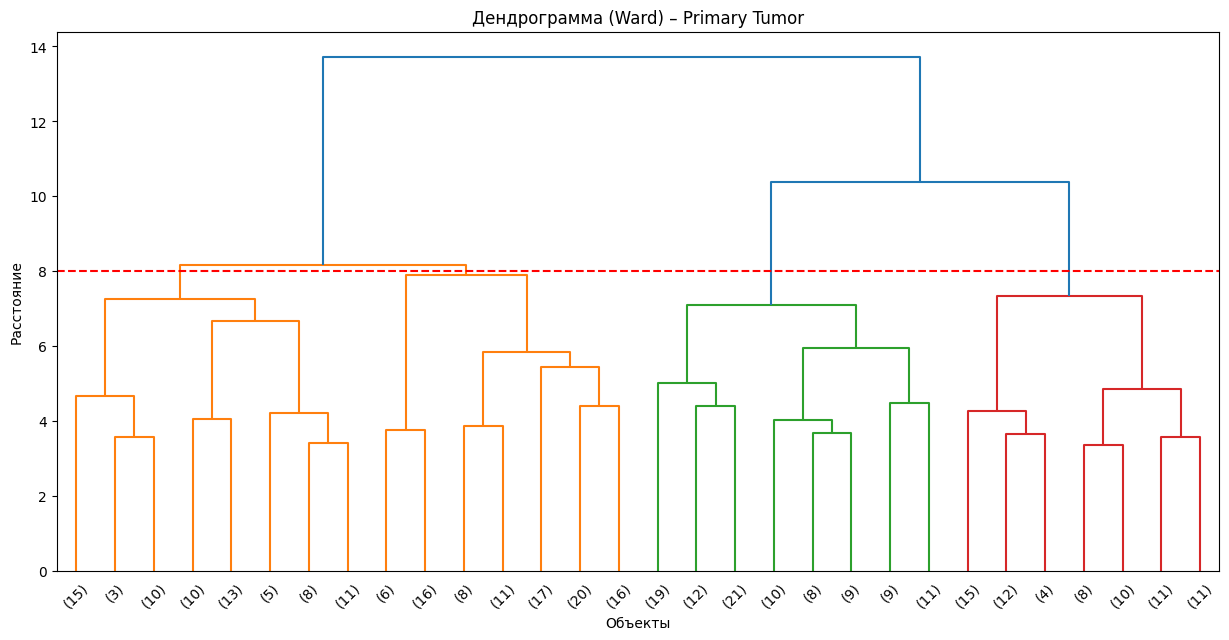

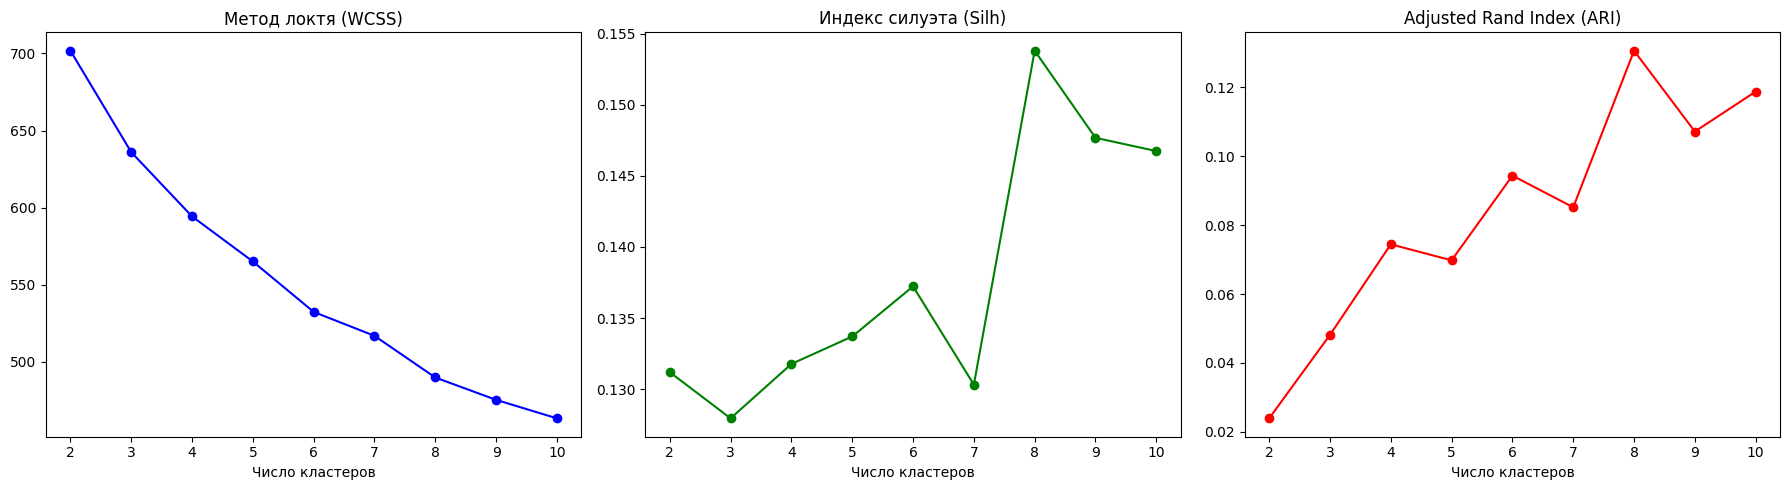

Оптимальное k по ARI: 8, по силуэту: 8

K-Means Silhouette: 0.1538, ARI: 0.1305
Fuzzy C-Means Silhouette: -0.0405, ARI: 0.0432


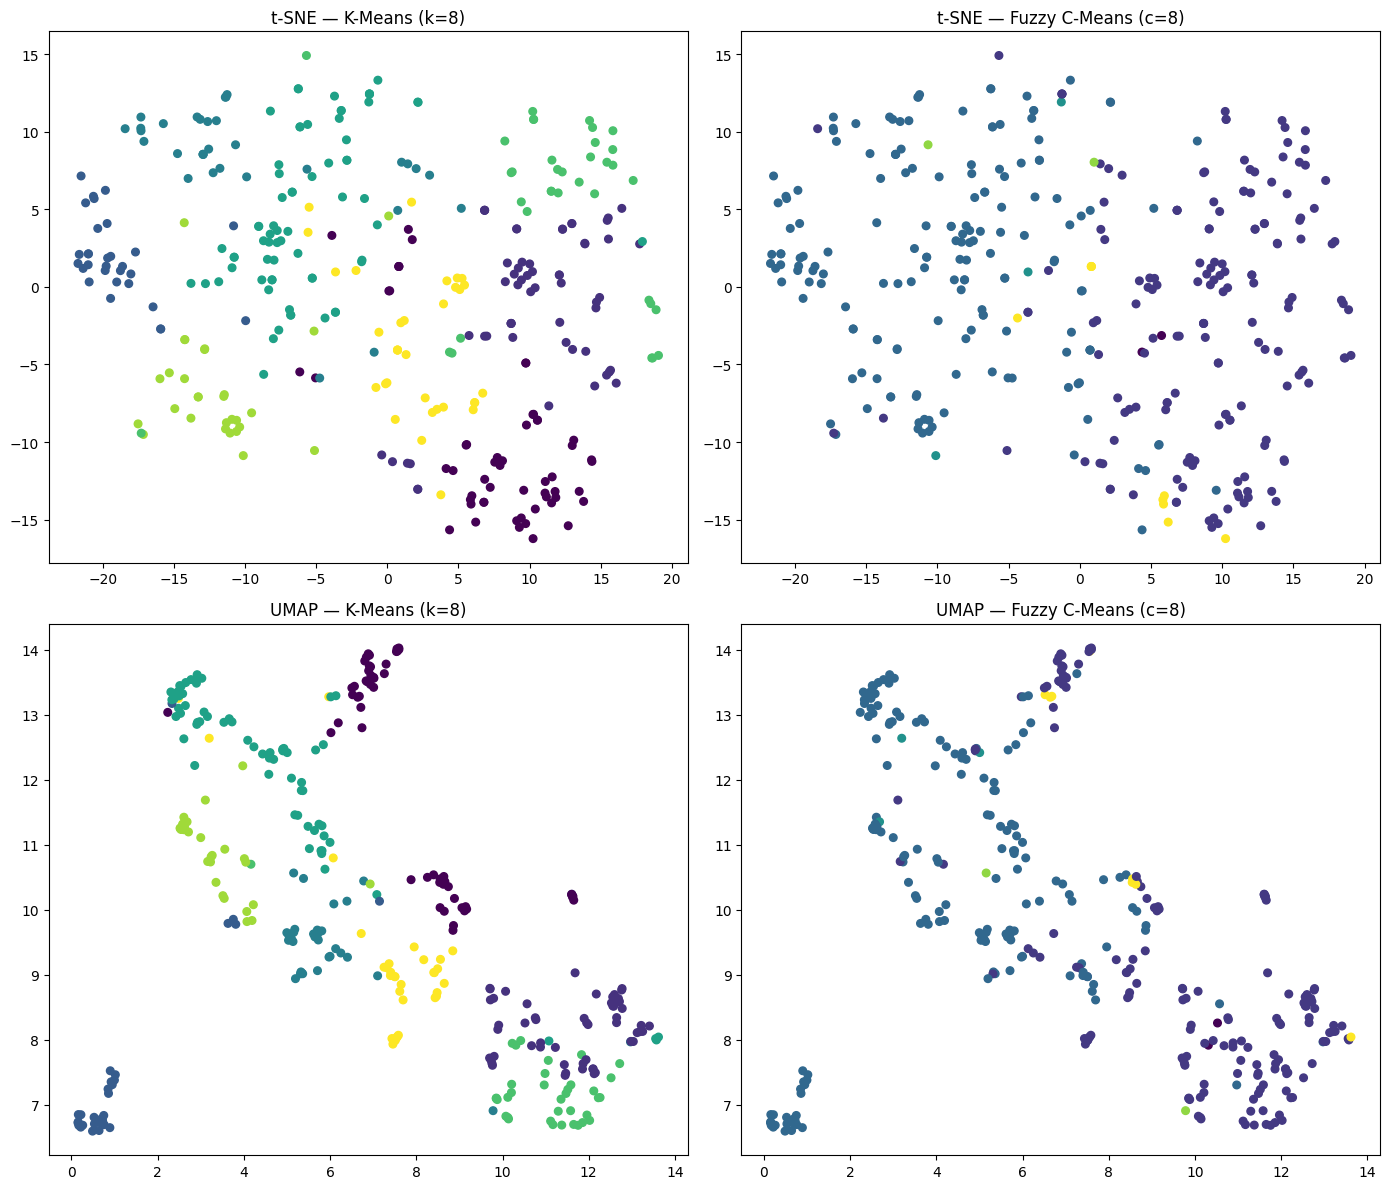

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.manifold import TSNE
import umap
import skfuzzy as fuzz
import warnings
warnings.filterwarnings('ignore')

columns = [
    "class", "age", "sex", "histologic_type", "degree_of_diffe", "bone", "bone_marrow",
    "lung", "pleura", "peritoneum", "liver", "brain", "skin", "neck", "supraclavicular",
    "axillar", "mediastinum", "abdominal"
]
df = pd.read_csv('primary-tumor.data', names=columns, na_values="?")

y_true = df['class']
X = df.drop('class', axis=1)

for col in X.columns:
    X[col] = X[col].fillna(X[col].mode()[0] if not X[col].mode().empty else 0)

X = X.astype('category').apply(lambda x: x.cat.codes)

scaler = preprocessing.MinMaxScaler()
X_scaled = scaler.fit_transform(X)

y_encoded = pd.factorize(y_true)[0]

print(f"Объектов: {X_scaled.shape[0]}, признаков: {X_scaled.shape[1]}")

distance_matrix = linkage(X_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(15, 7))
dendrogram(distance_matrix, truncate_mode='lastp', p=30, leaf_font_size=10)
plt.title("Дендрограмма (Ward) – Primary Tumor")
plt.xlabel("Объекты")
plt.ylabel("Расстояние")
plt.axhline(y=8, color='r', linestyle='--')
plt.show()


sil_scores = []
ari_scores = []
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, metric='euclidean'))
    ari_scores.append(adjusted_rand_score(y_encoded, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Метод локтя (WCSS)')
axes[0].set_xlabel('Число кластеров')
axes[1].plot(K_range, sil_scores, 'go-')
axes[1].set_title('Индекс силуэта (Silh)')
axes[1].set_xlabel('Число кластеров')
axes[2].plot(K_range, ari_scores, 'ro-')
axes[2].set_title('Adjusted Rand Index (ARI)')
axes[2].set_xlabel('Число кластеров')
plt.tight_layout()
plt.show()

optimal_k_ari = K_range[np.argmax(ari_scores)]
optimal_k_sil = K_range[np.argmax(sil_scores)]
print(f"Оптимальное k по ARI: {optimal_k_ari}, по силуэту: {optimal_k_sil}")

best_k = optimal_k_ari

kmeans = KMeans(n_clusters=best_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T, c=best_k, m=2, error=0.005, maxiter=300, seed=42
)
fcm_labels = np.argmax(u, axis=0)

print(f"\nK-Means Silhouette: {silhouette_score(X_scaled, kmeans_labels):.4f}, ARI: {adjusted_rand_score(y_encoded, kmeans_labels):.4f}")
print(f"Fuzzy C-Means Silhouette: {silhouette_score(X_scaled, fcm_labels):.4f}, ARI: {adjusted_rand_score(y_encoded, fcm_labels):.4f}")


tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

umap_reducer = umap.UMAP(random_state=42)
X_umap = umap_reducer.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='viridis', s=30)
axes[0, 0].set_title(f't-SNE — K-Means (k={best_k})')

axes[0, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=fcm_labels, cmap='viridis', s=30)
axes[0, 1].set_title(f't-SNE — Fuzzy C-Means (c={best_k})')

axes[1, 0].scatter(X_umap[:, 0], X_umap[:, 1], c=kmeans_labels, cmap='viridis', s=30)
axes[1, 0].set_title(f'UMAP — K-Means (k={best_k})')

axes[1, 1].scatter(X_umap[:, 0], X_umap[:, 1], c=fcm_labels, cmap='viridis', s=30)
axes[1, 1].set_title(f'UMAP — Fuzzy C-Means (c={best_k})')

plt.tight_layout()
plt.show()